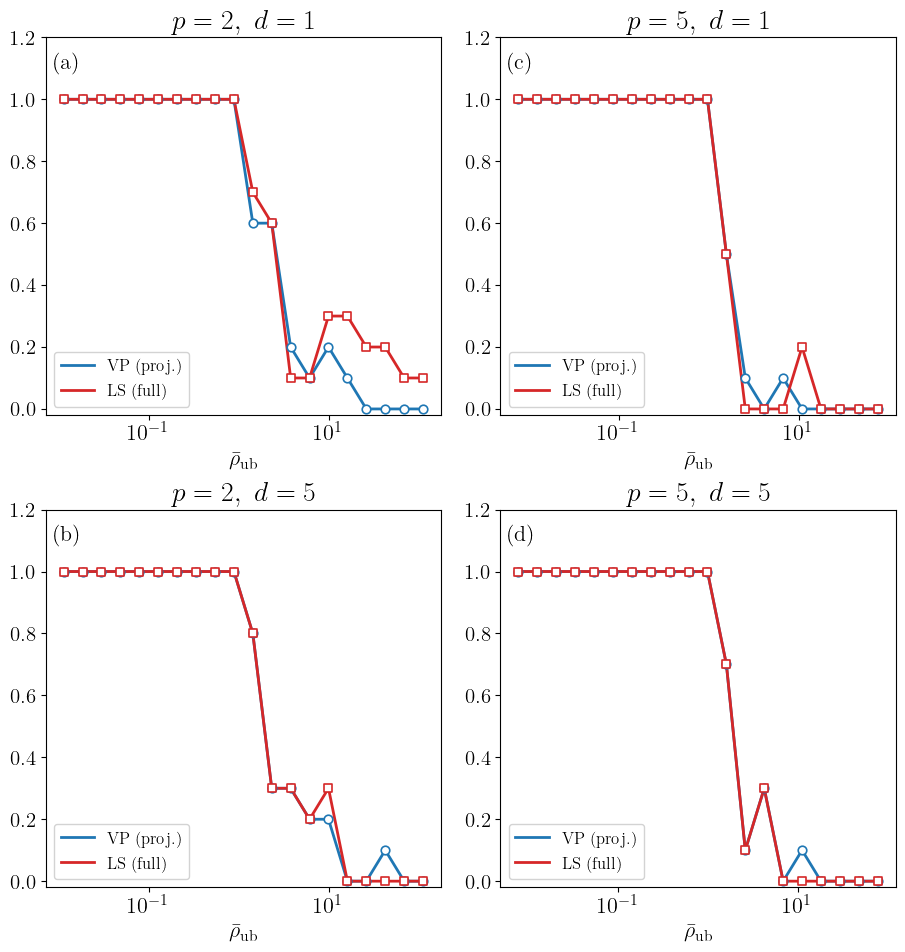

In [64]:
using PyPlot
using LaTeXStrings
using DelimitedFiles

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# ---------------- helpers ----------------
safe_std(v) = (any(isnan.(v)) ? replace(v, NaN => 0.0) : v)

"""
load_success_both_vs_rhoUB(path)

Expected CSV columns (header order from the new scheme):
p,d,idx,rho_ub,mu_min_mean,mu_min_std,min_eigval_mean,min_eigval_std,
conv_vp_mean,conv_vp_std,conv_ls_mean,conv_ls_std,radius_upper,radius_lower
"""
function load_success_both_vs_rhoUB(path::AbstractString)
    data = readdlm(path, ',', skipstart=1)

    p  = Int.(round.(Float64.(data[:, 1])))
    d  = Int.(round.(Float64.(data[:, 2])))

    rho_ub = Float64.(data[:, 4])

    mineig_m = Float64.(data[:, 7])
    mineig_s = Float64.(data[:, 8])

    conv_vp_m = Float64.(data[:, 9])
    conv_vp_s = Float64.(data[:,10])

    conv_ls_m = Float64.(data[:,11])
    conv_ls_s = Float64.(data[:,12])

    rad_up = Float64.(data[:,13])
    rad_lo = Float64.(data[:,14])

    B = Dict{Tuple{Int,Int}, NamedTuple}()
    for (pi, di) in unique(zip(p, d))
        idx = findall((p .== pi) .& (d .== di))
        isempty(idx) && continue

        ord = sortperm(rho_ub[idx])
        ii  = idx[ord]

        # radius_* are constant per (p,d) (same repeated down the rows); take first after sorting
        B[(pi,di)] = (
            x          = rho_ub[ii],
            mineig_m   = mineig_m[ii],
            mineig_s   = mineig_s[ii],
            conv_vp_m  = conv_vp_m[ii],
            conv_vp_s  = conv_vp_s[ii],
            conv_ls_m  = conv_ls_m[ii],
            conv_ls_s  = conv_ls_s[ii],
            rad_up     = rad_up[ii][1],
            rad_lo     = rad_lo[ii][1],
        )
    end
    return B
end

# ---------------- load ONE CSV ----------------
path = "results/noisy_convergence_comparison_dB=Inf_u=2.csv"   # <-- change me
B = load_success_both_vs_rhoUB(path)

pd_list = sort!(collect(keys(B)))
@assert !isempty(pd_list) "No (p,d) pairs found in $path."

# ---------------- layout ----------------
if length(pd_list) == 4
    fig, axs = subplots(2, 2, figsize=(10,10), constrained_layout=false)
    axs = vec(axs)
else
    fig, axs = subplots(1, length(pd_list), figsize=(10,5), constrained_layout=false)
    axs = length(pd_list) == 1 ? [axs] : vec(axs)
end

# ---------------- plot ----------------
for (k, (pi, di)) in enumerate(pd_list)
    ax = axs[k]
    Bi = B[(pi,di)]

    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.2)
    # optional bounds; set to nothing if you want autoscale
    # ax.set_xlim(1e-6, 1e1)

    ax.set_title(L"p=%$pi,\ d=%$di", fontsize=20)
    ax.set_xlabel(L"\bar{\rho}_{\mathrm{ub}}", fontsize=16)

    # ---- VP: blue circles ----
    ax.plot(
        Bi.x, Bi.conv_vp_m;
        color="tab:blue", linestyle="-", linewidth=2,
        zorder=5, label=L"\text{VP (proj.)}",
    )
    ax.scatter(
        Bi.x, Bi.conv_vp_m;
        color="tab:blue", marker="o", s=38,
        facecolors="white", linewidths=1.2,
        zorder=6,
    )

    # optional uncertainty band
    svp = safe_std(Bi.conv_vp_s)
    if any(svp .> 0)
        ax.fill_between(Bi.x, Bi.conv_vp_m .- svp, Bi.conv_vp_m .+ svp;
            color="tab:blue", alpha=0.10, linewidth=0, zorder=2)
    end

    # ---- LS: red squares ----
    ax.plot(
        Bi.x, Bi.conv_ls_m;
        color="tab:red", linestyle="-", linewidth=2,
        zorder=5, label=L"\text{LS (full)}",
    )
    ax.scatter(
        Bi.x, Bi.conv_ls_m;
        color="tab:red", marker="s", s=38,
        facecolors="white", linewidths=1.2,
        zorder=6,
    )

    # optional uncertainty band
    sls = safe_std(Bi.conv_ls_s)
    if any(sls .> 0)
        ax.fill_between(Bi.x, Bi.conv_ls_m .- sls, Bi.conv_ls_m .+ sls;
            color="tab:red", alpha=0.10, linewidth=0, zorder=2)
    end

    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=15)
    ax.legend(loc="lower left", fontsize=12, frameon=true, framealpha=0.85)
end

# panel labels
labs = ["(a)", "(b)", "(c)", "(d)"]
for (lab, ax) in zip(labs[1:min(end, length(axs))], axs)
    ax.text(0.02, 0.96, lab; transform=ax.transAxes,
        va="top", ha="left", fontsize=16,
        bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.95, wspace=0.15, hspace=0.25)
display(fig)

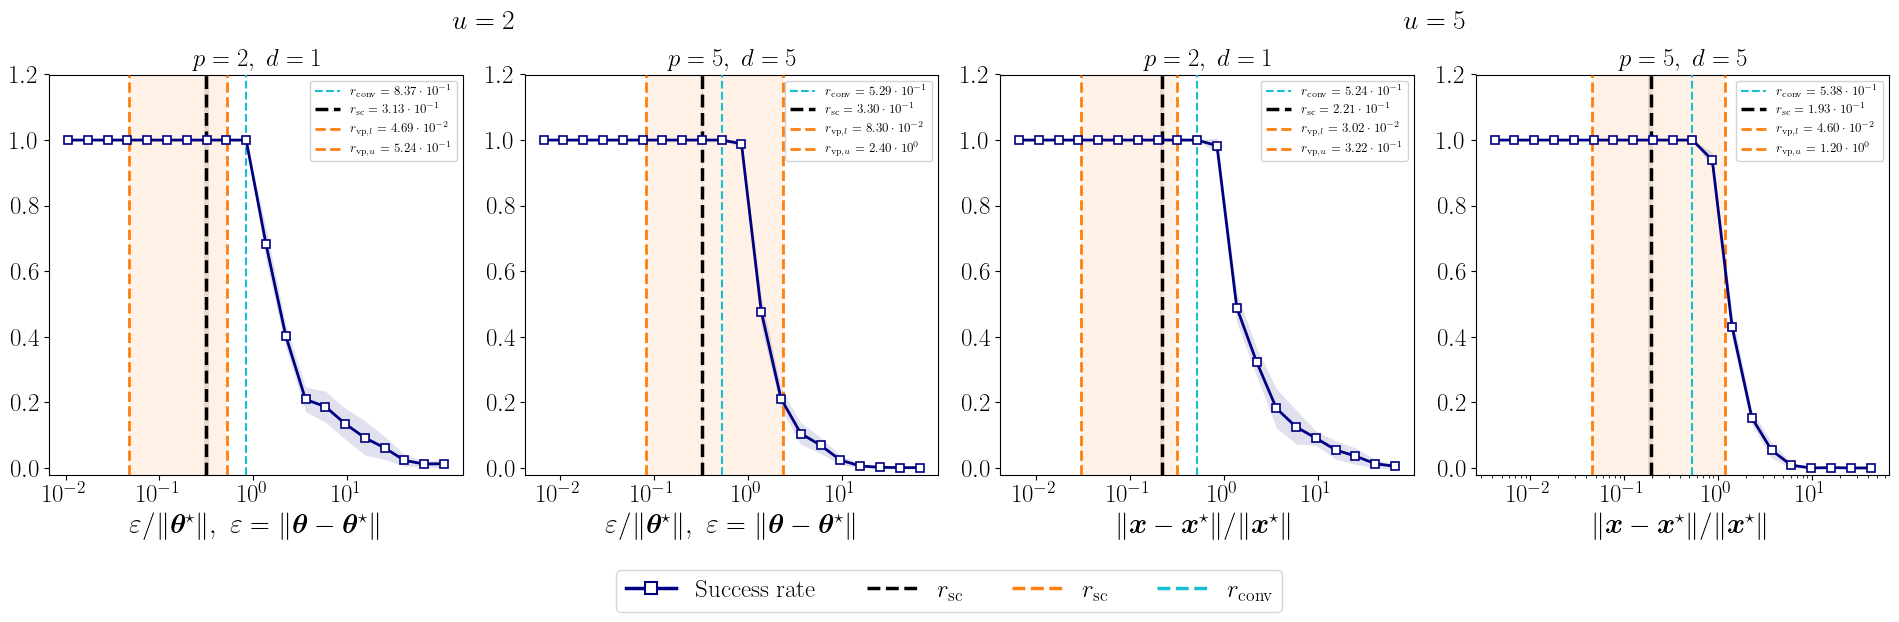

In [8]:
using PyPlot
using LaTeXStrings
using DelimitedFiles
using Printf

PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# ---------------- helpers ----------------

safe_std(v) = (any(isnan.(v)) ? replace(v, NaN => 0.0) : v)

function last_nonneg_crossing(x::AbstractVector, y::AbstractVector)
	n = length(x)
	@assert length(y) == n

	j = findfirst(<(0.0), y)
	j === nothing && return x[end]
	j == 1 && return NaN

	y0, y1 = y[j-1], y[j]
	x0, x1 = x[j-1], x[j]
	y0 == 0.0 && return x0

	t = y0 / (y0 - y1)
	return exp(log(x0) + t * (log(x1) - log(x0)))
end

# last x where y(x) >= thresh with log-x interpolation to first point below thresh
function last_above_crossing(x::AbstractVector, y::AbstractVector, thresh::Real)
	n = length(x)
	@assert length(y) == n

	# first index where y < thresh
	j = findfirst(<(thresh), y)
	j === nothing && return x[end]   # never drops below thresh
	j == 1 && return NaN             # already below at first point

	y0, y1 = y[j-1], y[j]
	x0, x1 = x[j-1], x[j]

	# if exactly at threshold at j-1
	y0 == thresh && return x0

	# linear interpolation in y, but in log-x domain
	t = (y0 - thresh) / (y0 - y1)    # in (0,1]
	return exp(log(x0) + t * (log(x1) - log(x0)))
end

function empirical_crossings(x, m, s)
	r_m    = last_nonneg_crossing(x, m)
	r_low  = last_nonneg_crossing(x, m - s)
	r_high = last_nonneg_crossing(x, m + s)
	if isfinite(r_low) && isfinite(r_high) && r_low > r_high
		r_low, r_high = r_high, r_low
	end
	return (r_m = r_m, r_low = r_low, r_high = r_high)
end

function plot_empirical_radius!(
	ax,
	r_m,
	r_low,
	r_high;
	line_color = "red",
	ribbon_alpha = 0.10,
	lw = 2.5,
)
	s = @sprintf("%.2e", r_m)
	parts = split(s, "e")
	mant = parts[1]
	expo = parse(Int, parts[2])    # removes leading zero automatically

	label_str = latexstring("r_{\\mathrm{sc}} = $mant \\cdot 10^{$expo}")

	if isfinite(r_m)
		ax.axvline(
			r_m;
			color = line_color,
			linestyle = "--",
			linewidth = lw,
			zorder = 5,
			label=label_str,
		)
	end
	if isfinite(r_low) && isfinite(r_high)
		lo, hi = (r_low <= r_high) ? (r_low, r_high) : (r_high, r_low)
		ax.axvspan(
			lo,
			hi;
			color = line_color,
			alpha = ribbon_alpha,
			linewidth = 0,
			zorder = 2,
		)
	end
end

function vband_lower_upper!(
	ax,
	xlow,
	xhigh;
	color = "darkgreen",
	alpha = 0.10,
	lw = 2,
	ls = "--",
	zorder = 3,
)
	if !(isfinite(xlow) && isfinite(xhigh))
		return
	end
	lo, hi = (xlow <= xhigh) ? (xlow, xhigh) : (xhigh, xlow)
	ax.axvspan(
		lo,
		hi;
		color = color,
		alpha = alpha,
		linewidth = 0,
		zorder = zorder-2,
	)

	s = @sprintf("%.2e", lo)
	parts = split(s, "e")
	mant = parts[1]
	expo = parse(Int, parts[2])    # removes leading zero automatically

	label_str_l = latexstring("r_{\\mathrm{vp}, l} = $mant \\cdot 10^{$expo}")

	ax.axvline(
		lo;
		color = color,
		linestyle = ls,
		linewidth = lw,
		zorder = zorder,
		label = label_str_l,
	)

	s = @sprintf("%.2e", hi)
	parts = split(s, "e")
	mant = parts[1]
	expo = parse(Int, parts[2])    # removes leading zero automatically

	label_str_u = latexstring("r_{\\mathrm{vp}, u} = $mant \\cdot 10^{$expo}")

	ax.axvline(
		hi;
		color = color,
		linestyle = ls,
		linewidth = lw,
		zorder = zorder,
		label = label_str_u,
	)
end

# ---------------- data loader ----------------
function load_basin_csv(path::AbstractString)
	data = readdlm(path, ',', skipstart = 1)

	p = Int.(round.(Float64.(data[:, 1])))
	d = Int.(round.(Float64.(data[:, 2])))

	x_old = Float64.(data[:, 4])

	mineig_m = Float64.(data[:, 7])
	mineig_s = Float64.(data[:, 8])

	conv_m = Float64.(data[:, 9])
	conv_s = Float64.(data[:, 10])

	rad_up = Float64.(data[:, 11])
	rad_lo = Float64.(data[:, 12])

	lifted_rho = Float64.(data[:, end])

	B = Dict{Tuple{Int, Int}, NamedTuple}()

	for (p_i, d_i) in unique(zip(p, d))
		idx = findall((p .== p_i) .& (d .== d_i))
		isempty(idx) && continue

		# ---- choose x-axis here ----
		# If you want lifted rho on x-axis, replace x_old by lifted_rho below (and sort by it).
		ord = sortperm(x_old[idx])
		ii  = idx[ord]

		B[(p_i, d_i)] = (
			x        = x_old[ii],          # <-- change to lifted_rho[ii] if desired
			mineig_m = mineig_m[ii],
			mineig_s = mineig_s[ii],
			conv_m   = conv_m[ii],
			conv_s   = conv_s[ii],
			rad_up   = rad_up[ii][1],
			rad_lo   = rad_lo[ii][1],
			# keep if you want access later:
			lifted_rho = lifted_rho[ii],
		)
	end

	return B
end

# ---------------- paths ----------------
path_u2 = "results/noisy_convergence_lifted_norm_vp_dB=0.0_u=2.csv"
path_u5 = "results/noisy_convergence_lifted_norm_vp_dB=0.0_u=5.csv"

B2 = load_basin_csv(path_u2)
B5 = load_basin_csv(path_u5)

# Use common (p,d) keys so panel layout matches
# pd_list = sort!(collect(intersect(keys(B2), keys(B5))))
pd_list = [(2,1), (5,5)]
# @assert length(pd_list) == 4 "Expected 4 (p,d) pairs in both files; got $(length(pd_list))."

# ---------------- layout: 2 rows x 4 cols ----------------
fig, axs = subplots(1, 4, figsize = (20, 5), constrained_layout = false)
axs = reshape(axs, 1, 4)  # axs[row, col]

# map k=1..4 to a 2x2 block coordinates
block_pos(k) = (k <= 2) ? (1, k) : (2, k-2)  # (row, col) within a 2x2 block

function plot_one_panel!(ax, Bi; title_str = "", show_legend = true)
	ax.set_xscale("log")
	ax.set_xticks([1e-2, 1e-1, 1e0, 1e1])
	ax.set_ylim(-0.02, 1.2)
	ax.set_title(title_str, fontsize = 18)

	ax.plot(
		Bi.x, Bi.conv_m;
		color = "navy", linestyle = "-", linewidth = 2,
		marker = "s", markersize = 5.5,
		markerfacecolor = "white", markeredgewidth = 1.2,
		markeredgecolor = "navy",
		zorder = 6, label = ""
	)

	sconv = safe_std(Bi.conv_s)
	if any(sconv .> 0)
		ax.fill_between(Bi.x, Bi.conv_m .- sconv, Bi.conv_m .+ sconv;
			color = "navy", alpha = 0.12, linewidth = 0, zorder = 3)
	end

	# --- empirical convergence radius from success-rate curve ---
	# threshold can be changed (0.5 is a common “50% success” radius)
	conv_thresh = 1.0
	r_conv = last_above_crossing(Bi.x, Bi.conv_m, conv_thresh)

	if isfinite(r_conv)
		# 2 significant digits scientific notation
		s = @sprintf("%.2e", r_conv)   # e.g. "8.35e-01"

		parts = split(s, "e")
		mant = parts[1]
		expo = parse(Int, parts[2])    # removes leading zero automatically

		label_str = latexstring("r_{\\mathrm{conv}} = $mant \\cdot 10^{$expo}")

		ax.axvline(
			r_conv;
			color = "tab:cyan", linestyle = "--", linewidth = 1.5, alpha = 1.0,
			zorder = 4,
			label = label_str,
		)
	end

	cr = empirical_crossings(Bi.x, Bi.mineig_m, Bi.mineig_s)
	plot_empirical_radius!(
		ax,
		cr.r_m,
		cr.r_low,
		cr.r_high;
		line_color = "black",
		ribbon_alpha = 0.10,
		lw = 2.5,
	)

	vband_lower_upper!(
		ax,
		Bi.rad_lo,
		Bi.rad_up;
		color = "tab:orange",
		alpha = 0.10,
		lw = 2,
		ls = "--",
		zorder = 4,
	)

	ax.tick_params(axis = "x", labelsize = 18)
	ax.tick_params(axis = "y", labelsize = 18)
	ax.legend(
		loc = "upper right",
		fontsize = 9,
		frameon = true,
		framealpha = 0.85,
	)

end

# ---------------- plot all 8 panels ----------------
# panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]
lab_idx = 1

for (k, (pi, di)) in enumerate(pd_list)
	# position inside a 2x2 block
	(r, c) = block_pos(k)

	# left block (u=2) occupies cols 1-2
	ax2 = axs[r, c]
	plot_one_panel!(
		ax2,
		B2[(pi, di)];
		title_str = latexstring("p=$pi,\\; d=$di"),
		show_legend = (k==1),
	)

	# ax2.text(0.02, 0.96, panel_labels[lab_idx]; transform = ax2.transAxes,
	# 	va = "top", ha = "left", fontsize = 14,
	# 	bbox = Dict("facecolor"=>"white", "alpha"=>0.7, "edgecolor"=>"none"))


	ax2.set_xlabel(L"\varepsilon/\|\bm{\theta}^\star\|,\ \varepsilon=\|\bm{\theta}-\bm{\theta}^\star\|", fontsize=20)

	lab_idx += 1

	# right block (u=5) occupies cols 3-4
	ax5 = axs[r, c+2]

	plot_one_panel!(
		ax5,
		B5[(pi, di)];
		title_str = latexstring("p=$pi,\\; d=$di"),
		show_legend = (k==1),
	)

	# ax5.text(0.02, 0.96, panel_labels[lab_idx]; transform = ax5.transAxes,
	# 	va = "top", ha = "left", fontsize = 14,
	# 	bbox = Dict("facecolor"=>"white", "alpha"=>0.7, "edgecolor"=>"none"))

	
	ax5.set_xlabel(L"\|\bm{x}-\bm{x}^\star\|/\|\bm{x}^\star\|", fontsize=20)


	lab_idx += 1
end

# Optional: big column headers (cleaner than repeating "u=2/u=5" in every title)
axs[1, 1].text(
	1.05,
	1.1,
	L"u=2";
	transform = axs[1, 1].transAxes,
	ha = "center",
	va = "bottom",
	fontsize = 20,
)

axs[1, 3].text(
	1.05,
	1.1,
	L"u=5";
	transform = axs[1, 3].transAxes,
	ha = "center",
	va = "bottom",
	fontsize = 20,
)

fig.subplots_adjust(
	left = 0.07,
	right = 0.99,
	bottom = 0.10,
	top = 0.90,
	wspace = 0.15,
	hspace = 0.2,
)

const mpl = PyPlot.matplotlib

success_label = mpl.lines.Line2D(
    [], [];
    color="navy",
    linestyle="-",
    linewidth=2.5,
    marker="s",              # square marker
    markersize=8,
    markerfacecolor="white",
    markeredgecolor="navy",
    markeredgewidth=1.5,
)
conv_rad        = mpl.lines.Line2D([], []; color="black", linestyle="--", linewidth=2.5)
vp_rad          = mpl.lines.Line2D([], []; color="tab:orange", linestyle="--", linewidth=2.5)
convergence_rad = mpl.lines.Line2D([], []; color="tab:cyan", linestyle="--", linewidth=2.5)

fig.legend([success_label, conv_rad, vp_rad, convergence_rad],
           ["Success rate", L"r_\mathrm{sc}", L"r_\mathrm{sc}", L"r_\mathrm{conv}"];
    loc="lower center", ncol=4, frameon=true, bbox_to_anchor=(0.52, -0.2), fontsize=18)



mkpath("figures")
savefig("figures/tsp_vp_success_rate.pdf", bbox_inches = "tight")
display(fig)


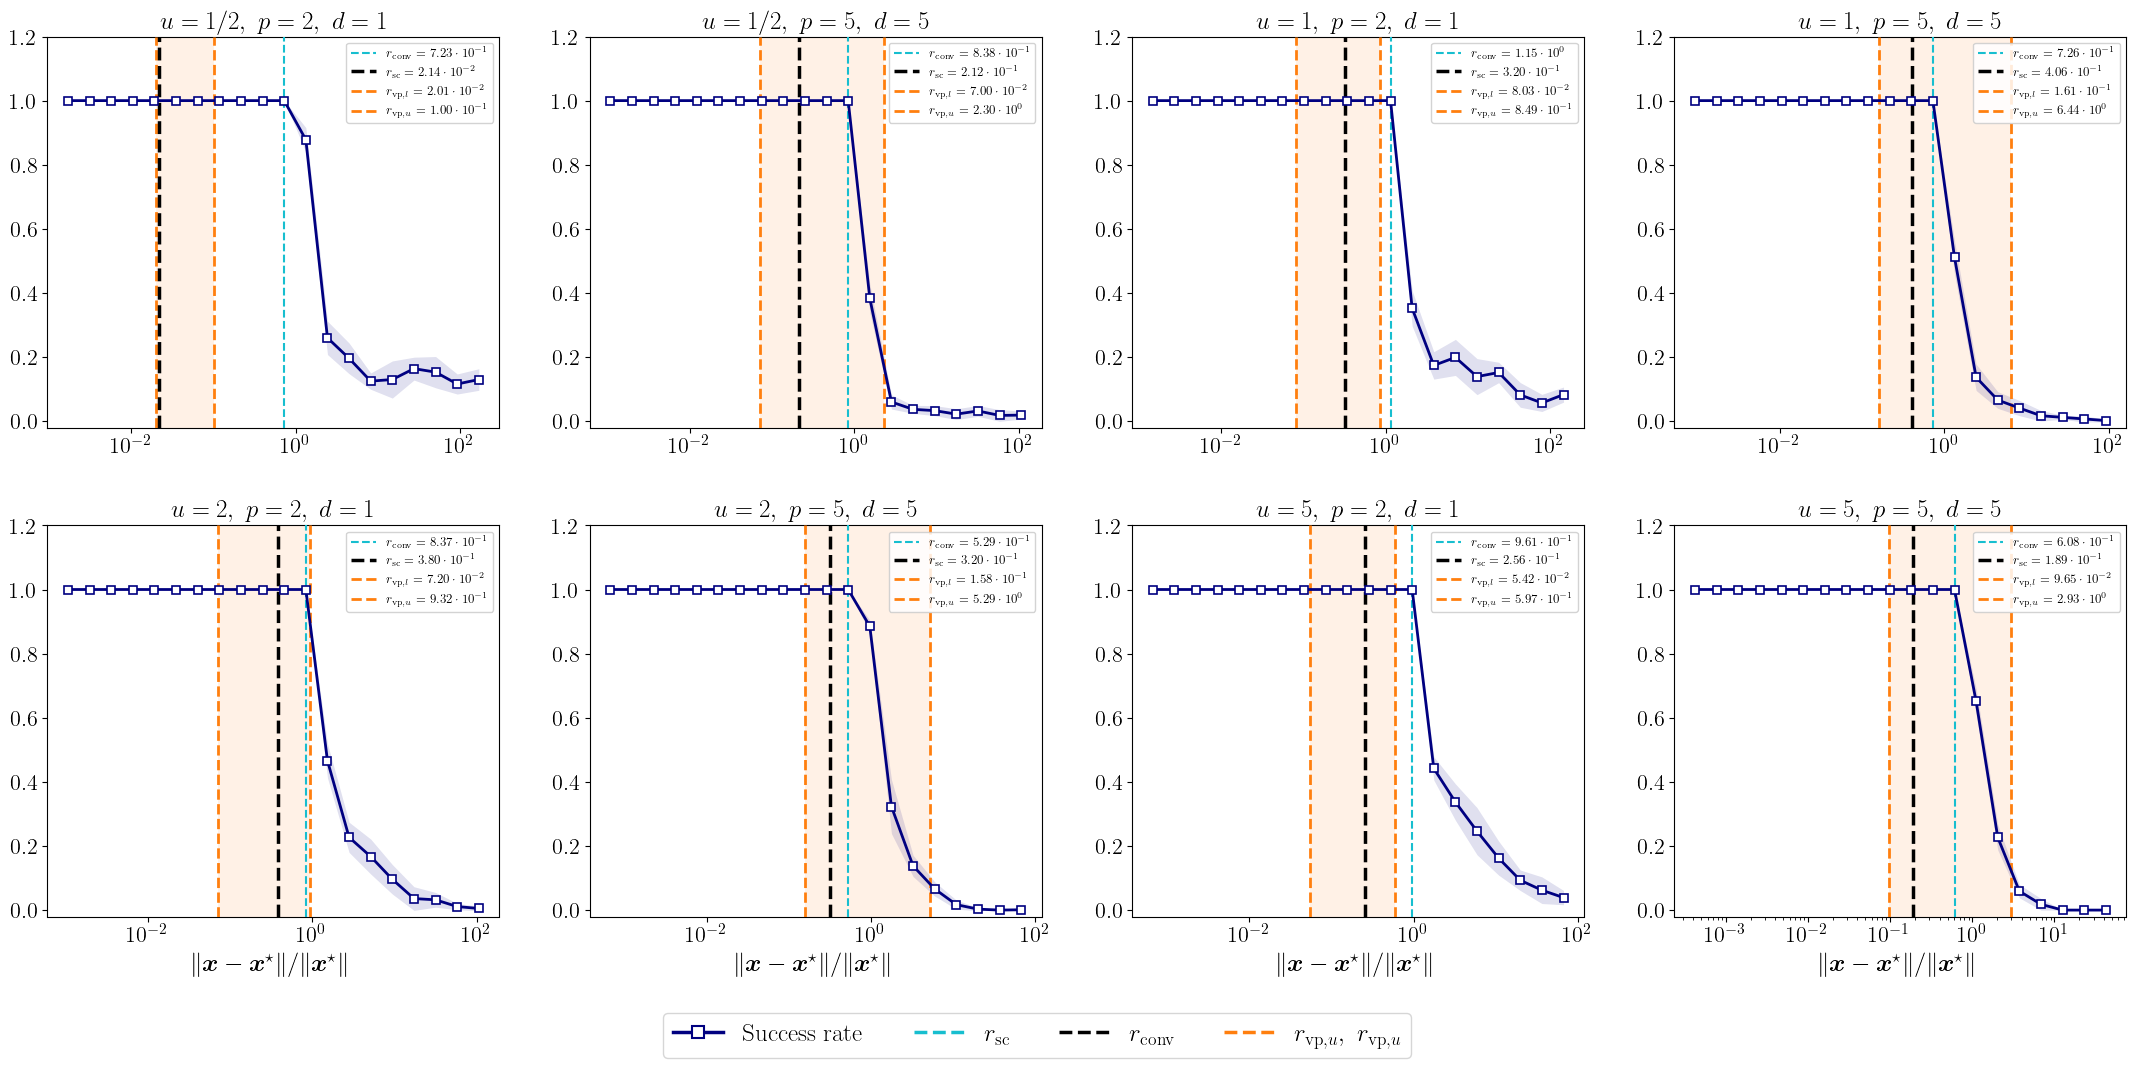

In [9]:
using PyPlot
using LaTeXStrings
using DelimitedFiles
using Printf

PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# ---------------- helpers ----------------
safe_std(v) = (any(isnan.(v)) ? replace(v, NaN => 0.0) : v)

function last_nonneg_crossing(x::AbstractVector, y::AbstractVector)
    n = length(x)
    @assert length(y) == n
    j = findfirst(<(0.0), y)
    j === nothing && return x[end]
    j == 1 && return NaN
    y0, y1 = y[j-1], y[j]
    x0, x1 = x[j-1], x[j]
    y0 == 0.0 && return x0
    t = y0 / (y0 - y1)
    return exp(log(x0) + t * (log(x1) - log(x0)))
end

# last x where y(x) >= thresh with log-x interpolation to first point below thresh
function last_above_crossing(x::AbstractVector, y::AbstractVector, thresh::Real)
    n = length(x)
    @assert length(y) == n
    j = findfirst(<(thresh), y)
    j === nothing && return x[end]
    j == 1 && return NaN

    y0, y1 = y[j-1], y[j]
    x0, x1 = x[j-1], x[j]
    y0 == thresh && return x0

    t = (y0 - thresh) / (y0 - y1)
    return exp(log(x0) + t * (log(x1) - log(x0)))
end

function empirical_crossings(x, m, s)
    r_m    = last_nonneg_crossing(x, m)
    r_low  = last_nonneg_crossing(x, m - s)
    r_high = last_nonneg_crossing(x, m + s)
    if isfinite(r_low) && isfinite(r_high) && r_low > r_high
        r_low, r_high = r_high, r_low
    end
    return (r_m = r_m, r_low = r_low, r_high = r_high)
end

# format with your exact scheme, but SAFE for usetex: wrap everything in $...$
function latex_sci_label(prefix_tex::AbstractString, x::Real)
    s = @sprintf("%.2e", x)              # e.g. "8.35e-01"
    parts = split(s, "e")
    mant = parts[1]
    expo = parse(Int, parts[2])
    return latexstring("\$$prefix_tex = $mant \\cdot 10^{$expo}\$")
end

function plot_empirical_radius!(
    ax, r_m, r_low, r_high;
    line_color="black", ribbon_alpha=0.10, lw=2.5,
)
    if isfinite(r_m)
        label_str = latex_sci_label("r_{\\mathrm{sc}}", r_m)
        ax.axvline(r_m; color=line_color, linestyle="--", linewidth=lw, zorder=5, label=label_str)
    end
    # if isfinite(r_low) && isfinite(r_high)
    #     lo, hi = (r_low <= r_high) ? (r_low, r_high) : (r_high, r_low)
    #     ax.axvspan(lo, hi; color=line_color, alpha=ribbon_alpha, linewidth=0, zorder=2)
    # end
end

function vband_lower_upper!(
    ax, xlow, xhigh;
    color="tab:orange", alpha=0.10, lw=2, ls="--", zorder=3,
)
    if !(isfinite(xlow) && isfinite(xhigh))
        return
    end
    lo, hi = (xlow <= xhigh) ? (xlow, xhigh) : (xhigh, xlow)
    ax.axvspan(lo, hi; color=color, alpha=alpha, linewidth=0, zorder=zorder-2)
    # ax.axvline(lo; color=color, linestyle=ls, linewidth=lw, zorder=zorder)


	s = @sprintf("%.2e", lo)
	parts = split(s, "e")
	mant = parts[1]
	expo = parse(Int, parts[2])    # removes leading zero automatically

	label_str_l = latexstring("r_{\\mathrm{vp}, l} = $mant \\cdot 10^{$expo}")

	ax.axvline(
		lo;
		color = color,
		linestyle = ls,
		linewidth = lw,
		zorder = zorder,
		label = label_str_l,
	)

    label_str_u = latex_sci_label("r_{\\mathrm{vp}, u}", hi)
    ax.axvline(hi; color=color, linestyle=ls, linewidth=lw, zorder=zorder, label=label_str_u)
end

# ---------------- data loader ----------------
function load_basin_csv(path::AbstractString)
    data = readdlm(path, ',', skipstart=1)

    p  = Int.(round.(Float64.(data[:, 1])))
    d  = Int.(round.(Float64.(data[:, 2])))

    x_old = Float64.(data[:, 4])

    mineig_m = Float64.(data[:, 7])
    mineig_s = Float64.(data[:, 8])

    conv_m = Float64.(data[:, 9])
    conv_s = Float64.(data[:, 10])

    rad_up = Float64.(data[:, 11])
    rad_lo = Float64.(data[:, 12])

    lifted_rho = Float64.(data[:, end])

    B = Dict{Tuple{Int,Int}, NamedTuple}()
    for (pi, di) in unique(zip(p, d))
        idx = findall((p .== pi) .& (d .== di))
        isempty(idx) && continue

        ord = sortperm(x_old[idx])
        ii  = idx[ord]

        B[(pi,di)] = (
            x          = x_old[ii],     # change to lifted_rho[ii] if you want
            mineig_m   = mineig_m[ii],
            mineig_s   = mineig_s[ii],
            conv_m     = conv_m[ii],
            conv_s     = conv_s[ii],
            rad_up     = rad_up[ii][1],
            rad_lo     = rad_lo[ii][1],
            lifted_rho = lifted_rho[ii],
        )
    end
    return B
end

# ---------------- plot one panel ----------------
function plot_one_panel!(ax, Bi; title_str=latexstring(""), show_legend=true)
    ax.set_xscale("log")
    # ax.set_xticks([1e-2, 1e-1, 1e0, 1e1])
    ax.set_ylim(-0.02, 1.2)
    ax.set_title(title_str, fontsize=18)

    ax.plot(
        Bi.x, Bi.conv_m;
        color="navy", linestyle="-", linewidth=2,
        marker="s", markersize=5.5,
        markerfacecolor="white", markeredgewidth=1.2,
        markeredgecolor="navy",
        zorder=6, label=""
    )

    sconv = safe_std(Bi.conv_s)
    if any(sconv .> 0)
        ax.fill_between(Bi.x, Bi.conv_m .- sconv, Bi.conv_m .+ sconv;
            color="navy", alpha=0.12, linewidth=0, zorder=3)
    end

    # empirical r_conv at threshold 1.0
    conv_thresh = 1.0
    r_conv = last_above_crossing(Bi.x, Bi.conv_m, conv_thresh)
    if isfinite(r_conv)
        label_str = latex_sci_label("r_{\\mathrm{conv}}", r_conv)
        ax.axvline(r_conv; color="tab:cyan", linestyle="--", linewidth=1.5, zorder=4, label=label_str)
    end

    # spectral crossing band
    cr = empirical_crossings(Bi.x, Bi.mineig_m, Bi.mineig_s)
    plot_empirical_radius!(ax, cr.r_m, cr.r_low, cr.r_high; line_color="black", ribbon_alpha=0.10, lw=2.5)

    # vp radius band
    vband_lower_upper!(ax, Bi.rad_lo, Bi.rad_up; color="tab:orange", alpha=0.10, lw=2, ls="--", zorder=4)

    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    if show_legend
        ax.legend(loc="upper right", fontsize=9, frameon=true, framealpha=0.85)
    end
end

# ---------------- paths ----------------
path_u05 = "results/noisy_convergence_lifted_norm_vp_dB=10.0_u=0.5.csv"
path_u1  = "results/noisy_convergence_lifted_norm_vp_dB=10.0_u=1.csv"
path_u2  = "results/noisy_convergence_lifted_norm_vp_dB=10.0_u=2.csv"
path_u5  = "results/noisy_convergence_lifted_norm_vp_dB=10.0_u=5.csv"

B05 = load_basin_csv(path_u05)
B1  = load_basin_csv(path_u1)
B2  = load_basin_csv(path_u2)
B5  = load_basin_csv(path_u5)

pd_list = [(2,1), (5,5)]
@assert all(haskey(B05, k) for k in pd_list) "u=0.5 missing some (p,d)"
@assert all(haskey(B2,  k) for k in pd_list) "u=1 missing some (p,d)"
@assert all(haskey(B2,  k) for k in pd_list) "u=2 missing some (p,d)"
@assert all(haskey(B5,  k) for k in pd_list) "u=5 missing some (p,d)"

# ---------------- layout: 2 rows × 4 cols ----------------
# Row 1: u=0.5 uses centered cols 2-3
# Row 2: u=2 uses cols 1-2, u=5 uses cols 3-4
fig, axs = subplots(2, 4, figsize=(22, 11), constrained_layout=false)
axs = Array(axs)

# Top row (centered)
ax05_21 = axs[1, 1]
ax05_55 = axs[1, 2]
ax1_21  = axs[1, 3]
ax1_55  = axs[1, 4]

# Bottom row
ax2_21  = axs[2, 1]
ax2_55  = axs[2, 2]
ax5_21  = axs[2, 3]
ax5_55  = axs[2, 4]

# Turn off unused top-left and top-right slots
# axs[1,1].axis("off")
# axs[1,4].axis("off")

# ---------------- plot ----------------
plot_one_panel!(ax05_21, B05[(2,1)]; title_str=latexstring("u=1/2,\\; p=2,\\; d=1"), show_legend=true)
plot_one_panel!(ax05_55, B05[(5,5)]; title_str=latexstring("u=1/2,\\; p=5,\\; d=5"), show_legend=true)

plot_one_panel!(ax1_21, B1[(2,1)]; title_str=latexstring("u=1,\\; p=2,\\; d=1"), show_legend=true)
plot_one_panel!(ax1_55, B1[(5,5)]; title_str=latexstring("u=1,\\; p=5,\\; d=5"), show_legend=true)

plot_one_panel!(ax2_21,  B2[(2,1)];  title_str=latexstring("u=2,\\; p=2,\\; d=1"), show_legend=true)
plot_one_panel!(ax2_55,  B2[(5,5)];  title_str=latexstring("u=2,\\; p=5,\\; d=5"), show_legend=true)

plot_one_panel!(ax5_21,  B5[(2,1)];  title_str=latexstring("u=5,\\; p=2,\\; d=1"), show_legend=true)
plot_one_panel!(ax5_55,  B5[(5,5)];  title_str=latexstring("u=5,\\; p=5,\\; d=5"), show_legend=true)

# x labels only on bottom row
for ax in (ax2_21, ax2_55, ax5_21, ax5_55)
    ax.set_xlabel(L"\|\bm{x}-\bm{x}^\star\|/\|\bm{x}^\star\|", fontsize=18)
end

# ---------------- global titles ----------------
# fig.text(0.50, 0.97, L"u=0.5", ha="center", va="top", fontsize=22)
# fig.text(0.25, 0.49, L"u=2",   ha="center", va="bottom", fontsize=22)
# fig.text(0.75, 0.49, L"u=5",   ha="center", va="bottom", fontsize=22)

# ---------------- global legend ----------------
const mpl = PyPlot.matplotlib
success_label = mpl.lines.Line2D(
    [], [];
    color="navy", linestyle="-", linewidth=2.5,
    marker="s", markersize=8,
    markerfacecolor="white",
    markeredgecolor="navy",
    markeredgewidth=1.5,
)
conv_rad        = mpl.lines.Line2D([], []; color="black",     linestyle="--", linewidth=2.5)
convergence_rad = mpl.lines.Line2D([], []; color="tab:cyan",   linestyle="--", linewidth=2.5)
vp_rad          = mpl.lines.Line2D([], []; color="tab:orange", linestyle="--", linewidth=2.5)

fig.legend(
    [success_label, convergence_rad, conv_rad, vp_rad],
    ["Success rate", L"r_\mathrm{sc}", L"r_\mathrm{conv}", L"r_{\mathrm{vp},u} ,\ r_{\mathrm{vp},u}"];
    loc="lower center", ncol=4, frameon=true, bbox_to_anchor=(0.5, -0.02), fontsize=18
)

fig.subplots_adjust(left=0.05, right=0.995, bottom=0.12, top=0.92, wspace=0.20, hspace=0.25)

mkpath("figures")
savefig("figures/tsp_convergence_regions.pdf", bbox_inches="tight")
display(fig)

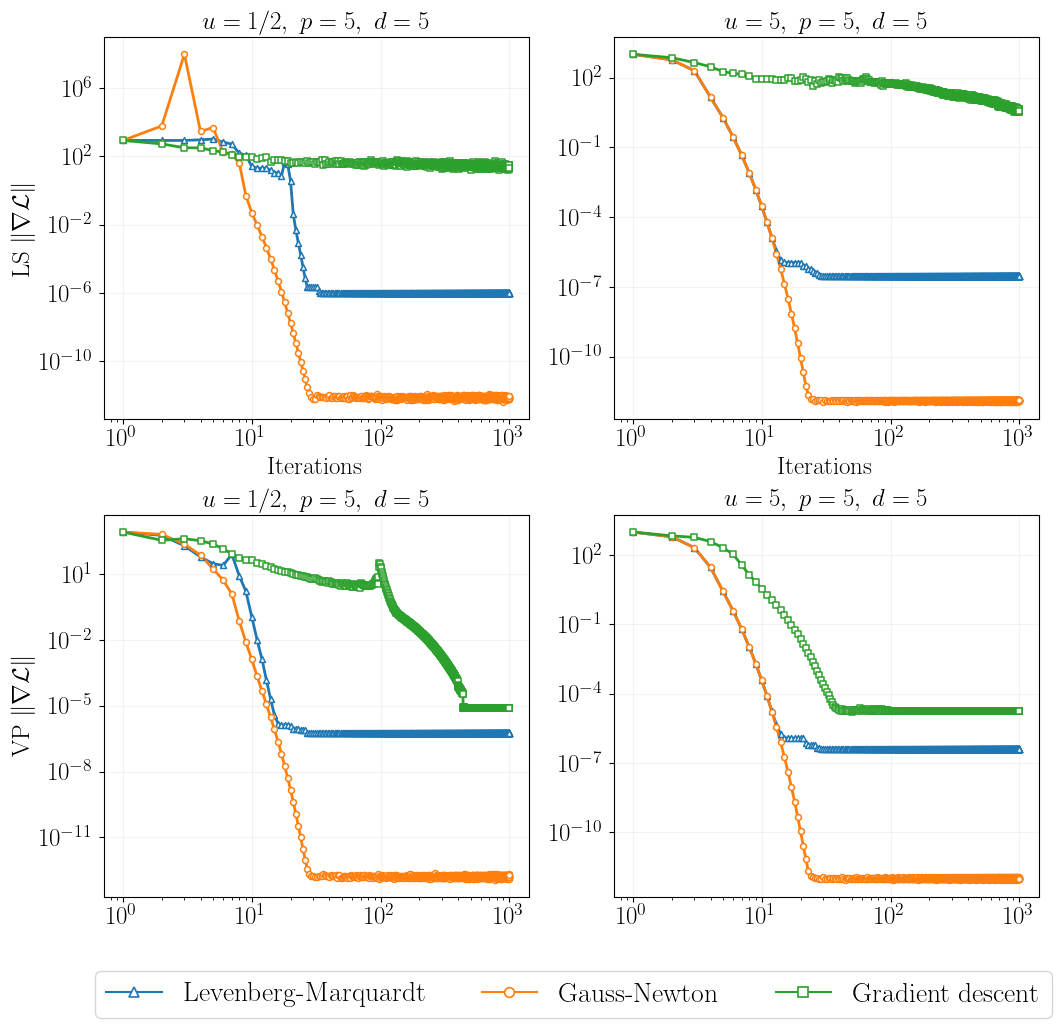

In [7]:
using PyPlot
using LaTeXStrings
using DelimitedFiles

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# ---------------- data loader (MEAN ONLY; grads only) ----------------
function load_traces_grad_mean_only(path::AbstractString)
    data = readdlm(path, ',', skipstart=1)

    p  = Int.(round.(Float64.(data[:, 1])))
    d  = Int.(round.(Float64.(data[:, 2])))
    it = Int.(round.(Float64.(data[:, 3])))

    col(j) = Float64.(data[:, j])

    # mean-only trace CSV layout you used:
    # vp_LM_grad_m = col(6), vp_GN_grad_m = col(10), vp_GD_grad_m = col(14)
    # ls_LM_grad_m = col(18), ls_GN_grad_m = col(22), ls_GD_grad_m = col(26)
    vp_LM_grad_m = col(6)
    vp_GN_grad_m = col(10)
    vp_GD_grad_m = col(14)

    ls_LM_grad_m = col(18)
    ls_GN_grad_m = col(22)
    ls_GD_grad_m = col(26)

    B = Dict{Tuple{Int,Int}, NamedTuple}()
    for (pi, di) in unique(zip(p, d))
        idx = findall((p .== pi) .& (d .== di))
        isempty(idx) && continue

        ord = sortperm(it[idx])
        ii  = idx[ord]

        B[(pi,di)] = (
            it = it[ii] .+ 1,  # start at 1

            vp_LM_grad_m = vp_LM_grad_m[ii],
            vp_GN_grad_m = vp_GN_grad_m[ii],
            vp_GD_grad_m = vp_GD_grad_m[ii],

            ls_LM_grad_m = ls_LM_grad_m[ii],
            ls_GN_grad_m = ls_GN_grad_m[ii],
            ls_GD_grad_m = ls_GD_grad_m[ii],
        )
    end

    return B
end

# ---------------- styling ----------------
methods = [
    ("LM", "tab:blue",   "-", "^"),
    ("GN", "tab:orange", "-", "o"),
    ("GD", "tab:green",  "-", "s"),
]

function style_grad_axis!(ax; ylabel=L"", xlabel=nothing, title=nothing)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(true, alpha=0.15)
    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    if xlabel !== nothing
        ax.set_xlabel(xlabel, fontsize=18)
    end
    if title !== nothing
        ax.set_title(title, fontsize=18)
    end
end

function plot_grad_curves!(ax, it, grads_dict)
    for (name, color, ls, marker) in methods
        g = grads_dict[name]
        ax.plot(it, g; color=color, linestyle=ls, linewidth=2, zorder=5)
        ax.scatter(it, g; color=color, marker=marker, s=18,
            facecolors="white", linewidths=1.1, zorder=6)
    end
end

function plot_slot_vp_ls!(ax_vp, ax_ls, Bi; title_str=nothing, show_xlabel=false, show_ylabel=false)
    it = Bi.it

    grads_vp = Dict(
        "LM" => Bi.vp_LM_grad_m,
        "GN" => Bi.vp_GN_grad_m,
        "GD" => Bi.vp_GD_grad_m,
    )
    grads_ls = Dict(
        "LM" => Bi.ls_LM_grad_m,
        "GN" => Bi.ls_GN_grad_m,
        "GD" => Bi.ls_GD_grad_m,
    )

    style_grad_axis!(ax_vp; ylabel = show_ylabel ? L"\mathrm{VP}\;\|\nabla \mathcal{L}\|" : "", title=title_str)

    style_grad_axis!(ax_ls; ylabel = show_ylabel ? L"\mathrm{LS}\;\|\nabla \mathcal{L}\|" : "", xlabel = show_xlabel ? "Iterations" : "", title=title_str)

    plot_grad_curves!(ax_vp, it, grads_vp)
    plot_grad_curves!(ax_ls, it, grads_ls)

    # ax_vp.tick_params(labelbottom=false)
end

# ---------------- paths ----------------
path_u05 = "results/trace_loss_grad_vp_vs_ls_dB=0.0_u=0.5_eps=0.1_K=1000.csv"
path_u2  = "results/trace_loss_grad_vp_vs_ls_dB=0.0_u=2_eps=0.1_K=1000.csv"
path_u5  = "results/trace_loss_grad_vp_vs_ls_dB=0.0_u=5_eps=0.1_K=1000.csv"

B05 = load_traces_grad_mean_only(path_u05)
B2  = load_traces_grad_mean_only(path_u2)
B5  = load_traces_grad_mean_only(path_u5)

pd_list = [(2,1), (5,5)]
@assert all(haskey(B05, k) for k in pd_list) "u=0.5 missing (p,d)"
@assert all(haskey(B2,  k) for k in pd_list) "u=2 missing (p,d)"
@assert all(haskey(B5,  k) for k in pd_list) "u=5 missing (p,d)"

title_21 = latexstring("p=2,\\; d=1")
title_55 = latexstring("p=5,\\; d=5")

# ---------------- layout (subplots-style, like your working snippet) ----------------
# 4 rows × 4 cols:
# rows 1-2: top triangle (u=0.5): VP row then LS row
# rows 3-4: bottom blocks (u=2 left, u=5 right): VP row then LS row
fig, axs = subplots(2, 2, figsize=(10, 10), constrained_layout=false)
axs = Array(axs)

# ---- pick axes (exactly like your example, just doubled rows for VP/LS) ----
# TOP triangle (u=0.5), centered in cols 2-3
# ax05_21_vp = axs[1, 1]
ax05_55_vp = axs[2, 1]

# ax05_21_ls = axs[2, 1]
ax05_55_ls = axs[1, 1]

# BOTTOM row blocks: u=2 in cols 1-2, u=5 in cols 3-4
# VP row
# ax2_21_vp  = axs[3, 1]
# ax2_55_vp  = axs[3, 2]
# ax5_21_vp  = axs[1, 3]
ax5_55_vp  = axs[2, 2]
# LS row
# ax2_21_ls  = axs[4, 1]
# ax2_55_ls  = axs[4, 2]
# ax5_21_ls  = axs[2, 3]
ax5_55_ls  = axs[1, 2]

# ---- Turn off unused slots (top-left/top-right + the two slots under them) ----
# for (r,c) in ((1,1),(1,4),(2,1),(2,4))
#     axs[r,c].axis("off")
# end

# ---------------- plot ----------------
# u=0.5 (no xlabel)
# plot_slot_vp_ls!(ax05_21_vp, ax05_21_ls, B05[(2,1)]; title_str=latexstring("u=1/2,\\;p=2,\\; d=1"), show_xlabel=true, show_ylabel=true)

plot_slot_vp_ls!(ax05_55_vp, ax05_55_ls, B05[(5,5)]; title_str=latexstring("u=1/2,\\;p=5,\\; d=5"), show_xlabel=true, show_ylabel=true)

# u=2 (xlabel on LS)
# plot_slot_vp_ls!(ax2_21_vp, ax2_21_ls, B2[(2,1)]; title_str=latexstring("u=2,\\;p=2,\\; d=1"), show_xlabel=true)
# plot_slot_vp_ls!(ax2_55_vp, ax2_55_ls, B2[(5,5)]; title_str=latexstring("u=2,\\;p=5,\\; d=5"), show_xlabel=true)

# u=5 (xlabel on LS)
# plot_slot_vp_ls!(ax5_21_vp, ax5_21_ls, B5[(2,1)]; title_str=latexstring("u=5,\\;p=2,\\; d=1"), show_xlabel=true, show_ylabel=false)

plot_slot_vp_ls!(ax5_55_vp, ax5_55_ls, B5[(5,5)]; title_str=latexstring("u=5,\\;p=5,\\; d=5"), show_xlabel=true, show_ylabel=false)

# ---------------- global titles ----------------
# fig.text(0.53, 0.985, L"u=0.5", ha="center", va="top", fontsize=22)
# fig.text(0.20, 0.52,  L"u=2",   ha="center", va="bottom", fontsize=22)
# fig.text(0.80, 0.52,  L"u=5",   ha="center", va="bottom", fontsize=22)

# ---------------- global legend ----------------
const mpl = PyPlot.matplotlib
hLM = mpl.lines.Line2D([], []; color="tab:blue",   linestyle="-", marker="^", markersize=7,
    markerfacecolor="white", markeredgewidth=1.2)
hGN = mpl.lines.Line2D([], []; color="tab:orange", linestyle="-", marker="o", markersize=7,
    markerfacecolor="white", markeredgewidth=1.2)
hGD = mpl.lines.Line2D([], []; color="tab:green",  linestyle="-", marker="s", markersize=7,
    markerfacecolor="white", markeredgewidth=1.2)

fig.legend(
    [hLM, hGN, hGD],
    [L"\mathrm{Levenberg\text{-}Marquardt}", L"\mathrm{Gauss\text{-}Newton}", L"\mathrm{Gradient\ descent}"];
    loc="lower center", ncol=3, frameon=true, bbox_to_anchor=(0.53, -0.055), fontsize=20
)

fig.subplots_adjust(left=0.06, right=0.995, bottom=0.08, top=0.94, wspace=0.2, hspace=0.25)

mkpath("figures")
savefig("figures/tsp_convergence_comparison_simplest.pdf", bbox_inches="tight")
display(fig)

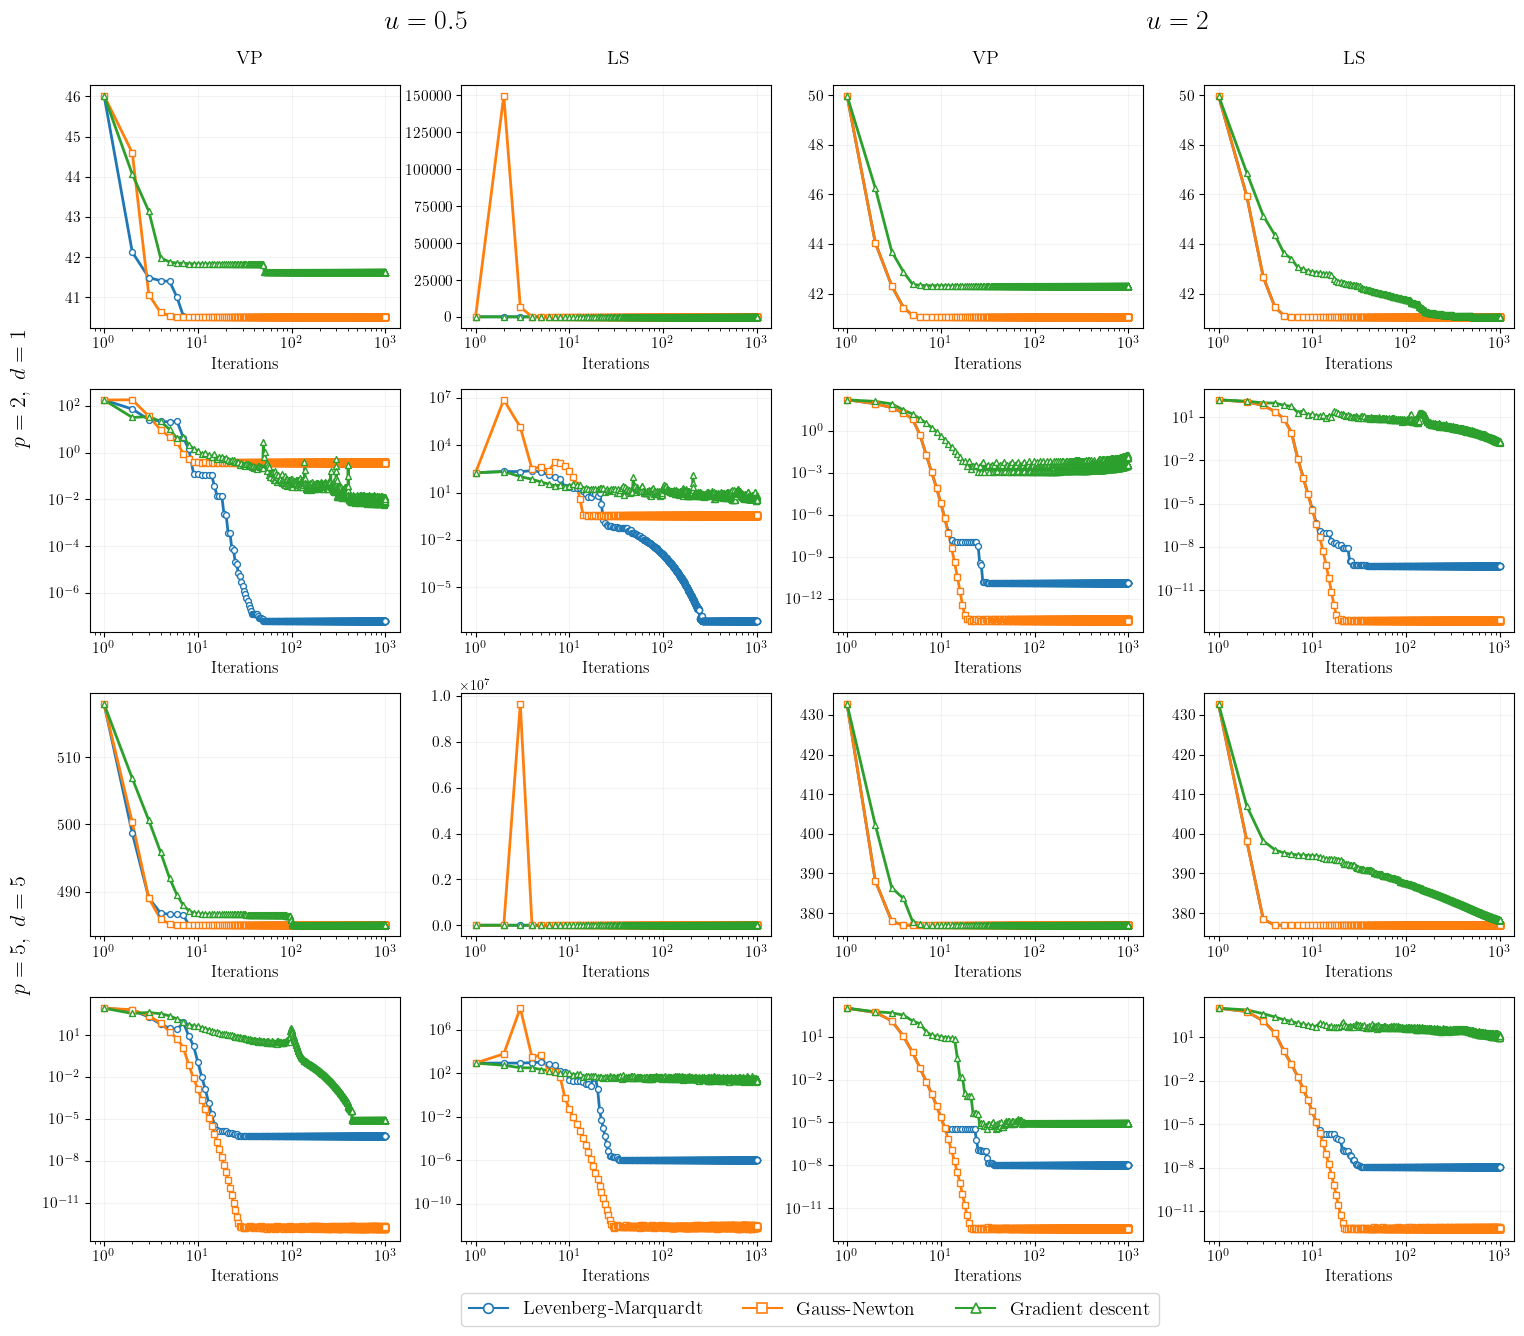

In [110]:
using PyPlot
using LaTeXStrings
using DelimitedFiles

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# ---------------- data loader ----------------
function load_traces_mean_only(path::AbstractString)
    data = readdlm(path, ',', skipstart=1)

    p  = Int.(round.(Float64.(data[:, 1])))
    d  = Int.(round.(Float64.(data[:, 2])))
    it = Int.(round.(Float64.(data[:, 3])))

    col(j) = Float64.(data[:, j])

    vp_LM_loss_m = col(4);  vp_LM_grad_m = col(6)
    vp_GN_loss_m = col(8);  vp_GN_grad_m = col(10)
    vp_GD_loss_m = col(12); vp_GD_grad_m = col(14)

    ls_LM_loss_m = col(16); ls_LM_grad_m = col(18)
    ls_GN_loss_m = col(20); ls_GN_grad_m = col(22)
    ls_GD_loss_m = col(24); ls_GD_grad_m = col(26)

    B = Dict{Tuple{Int,Int}, NamedTuple}()
    for (pi, di) in unique(zip(p, d))
        idx = findall((p .== pi) .& (d .== di))
        isempty(idx) && continue

        ord = sortperm(it[idx])
        ii  = idx[ord]

        B[(pi,di)] = (
            it = it[ii] .+ 1,   # shift so log-x works (k=0 -> 1)

            vp_LM_loss_m = vp_LM_loss_m[ii],
            vp_LM_grad_m = vp_LM_grad_m[ii],
            vp_GN_loss_m = vp_GN_loss_m[ii],
            vp_GN_grad_m = vp_GN_grad_m[ii],
            vp_GD_loss_m = vp_GD_loss_m[ii],
            vp_GD_grad_m = vp_GD_grad_m[ii],

            ls_LM_loss_m = ls_LM_loss_m[ii],
            ls_LM_grad_m = ls_LM_grad_m[ii],
            ls_GN_loss_m = ls_GN_loss_m[ii],
            ls_GN_grad_m = ls_GN_grad_m[ii],
            ls_GD_loss_m = ls_GD_loss_m[ii],
            ls_GD_grad_m = ls_GD_grad_m[ii],
        )
    end
    return B
end

# ---------------- style ----------------
methods = [
    ("LM", "tab:blue",   "-", "o"),
    ("GN", "tab:orange", "-", "s"),
    ("GD", "tab:green",  "-", "^"),
]

# Plot into an axis given (it, loss/grad) vector
function plot_curve!(ax, x, y, methodspec; ms=18)
    name, color, ls, marker = methodspec
    ax.plot(x, y; color=color, linestyle=ls, linewidth=2, zorder=5)
    ax.scatter(x, y; color=color, marker=marker, s=ms,
               facecolors="white", linewidths=1.0, zorder=6)
end

# ---------------- user inputs ----------------
path_u2 = "results/trace_loss_grad_vp_vs_ls_dB=0.0_u=0.5_eps=0.1_K=1000.csv"
path_u5 = "results/trace_loss_grad_vp_vs_ls_dB=0.0_u=2_eps=0.1_K=1000.csv"

B2 = load_traces_mean_only(path_u2)
B5 = load_traces_mean_only(path_u5)

# Ensure common pd list and stable ordering
pd_list = sort!(collect(intersect(keys(B2), keys(B5))))
@assert !isempty(pd_list) "No common (p,d) pairs between the two files."

P = length(pd_list)
nrows = 2P          # after transpose: two rows per (p,d): [loss; grad]
ncols = 4           # u=2: VP|LS, u=5: VP|LS  => 2 + 2

# ---------------- figure layout ----------------
# rows: (p1 loss, p1 grad, p2 loss, p2 grad, ...)
# cols: [u=2 VP, u=2 LS, u=5 VP, u=5 LS]
fig, axs = subplots(nrows, ncols, figsize=(16, 3.4*nrows), constrained_layout=false)
axs = Array(axs)

# ---------------- main plotting ----------------
for (j, (pi, di)) in enumerate(pd_list)
    Bi2 = B2[(pi,di)]
    Bi5 = B5[(pi,di)]

    r_loss = 2*(j-1) + 1
    r_grad = 2*(j-1) + 2

    # Axis assignment (TRANSPOSED layout)
    ax_u2_vp_loss = axs[r_loss, 1]
    ax_u2_ls_loss = axs[r_loss, 2]
    ax_u5_vp_loss = axs[r_loss, 3]
    ax_u5_ls_loss = axs[r_loss, 4]

    ax_u2_vp_grad = axs[r_grad, 1]
    ax_u2_ls_grad = axs[r_grad, 2]
    ax_u5_vp_grad = axs[r_grad, 3]
    ax_u5_ls_grad = axs[r_grad, 4]

    # --- common axis cosmetics ---
    # Loss axes: linear y; Grad axes: log y. All: log x.
    for ax in (ax_u2_vp_loss, ax_u2_ls_loss, ax_u5_vp_loss, ax_u5_ls_loss)
        ax.set_xscale("log")
        # ax.set_yscale("log")
        ax.tick_params(axis="x", labelsize=11)
        ax.tick_params(axis="y", labelsize=11)
        ax.grid(true, alpha=0.15)
        # keep y linear (default)
    end
    for ax in (ax_u2_vp_grad, ax_u2_ls_grad, ax_u5_vp_grad, ax_u5_ls_grad)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.tick_params(axis="x", labelsize=11)
        ax.tick_params(axis="y", labelsize=11)
        ax.grid(true, alpha=0.15)
    end

    # x-labels only on the bottom row (nice)
    for ax in (ax_u2_vp_loss, ax_u2_ls_loss, ax_u5_vp_loss, ax_u5_ls_loss,
               ax_u2_vp_grad, ax_u2_ls_grad, ax_u5_vp_grad, ax_u5_ls_grad)
        ax.set_xlabel("Iterations", fontsize=12)
    end

    # # --- row labels on the far left only (p,d group labels) ---
    # ax_u2_vp_loss.set_ylabel(L"p=%$pi,\ d=%$di\;\;\; L_k", fontsize=13)
    # ax_u2_vp_grad.set_ylabel(L"\|\nabla L_k\|", fontsize=13)

    # --- plot curves: u=2 ---
    for spec in methods
        nm = spec[1]
        # VP loss/grad
        plot_curve!(ax_u2_vp_loss, Bi2.it, getfield(Bi2, Symbol("vp_$(nm)_loss_m")), spec)
        plot_curve!(ax_u2_vp_grad, Bi2.it, getfield(Bi2, Symbol("vp_$(nm)_grad_m")), spec)
        # LS loss/grad
        plot_curve!(ax_u2_ls_loss, Bi2.it, getfield(Bi2, Symbol("ls_$(nm)_loss_m")), spec)
        plot_curve!(ax_u2_ls_grad, Bi2.it, getfield(Bi2, Symbol("ls_$(nm)_grad_m")), spec)
    end

    # --- plot curves: u=5 ---
    for spec in methods
        nm = spec[1]
        # VP loss/grad
        plot_curve!(ax_u5_vp_loss, Bi5.it, getfield(Bi5, Symbol("vp_$(nm)_loss_m")), spec)
        plot_curve!(ax_u5_vp_grad, Bi5.it, getfield(Bi5, Symbol("vp_$(nm)_grad_m")), spec)
        # LS loss/grad
        plot_curve!(ax_u5_ls_loss, Bi5.it, getfield(Bi5, Symbol("ls_$(nm)_loss_m")), spec)
        plot_curve!(ax_u5_ls_grad, Bi5.it, getfield(Bi5, Symbol("ls_$(nm)_grad_m")), spec)
    end
end

# ---- Row group labels (p,d) on far left ----
for (j, (pi, di)) in enumerate(pd_list)

    # Compute vertical center of the two rows belonging to this (p,d)
    r_loss = 2*(j-1) + 1
    r_grad = 2*(j-1) + 2

    # Get axis positions in figure coordinates
    pos_loss = axs[r_loss, 1].get_position()
    pos_grad = axs[r_grad, 1].get_position()

    y_center = (pos_loss.y0 + pos_grad.y1) / 2 + 0.01

    fig.text(0.05, y_center,
             L"p=%$pi,\ d=%$di",
             ha="left", va="center", 
             rotation = 90,
             fontsize=16)
end

# ---------------- global titles (two u-blocks) ----------------
# Centers of the two 2-column blocks: left block at ~0.25, right block at ~0.75
fig.text(0.31, 0.985, L"u=0.5", ha="center", va="top", fontsize=20)
fig.text(0.78, 0.985, L"u=2", ha="center", va="top", fontsize=20)


# Column headers within each block
fig.text(0.2, 0.955, L"\mathrm{VP}", ha="center", va="top", fontsize=14)
fig.text(0.43, 0.955, L"\mathrm{LS}", ha="center", va="top", fontsize=14)
fig.text(0.66, 0.955, L"\mathrm{VP}", ha="center", va="top", fontsize=14)
fig.text(0.89, 0.955, L"\mathrm{LS}", ha="center", va="top", fontsize=14)

# ---------------- global legend ----------------
const mpl = PyPlot.matplotlib
hLM = mpl.lines.Line2D([], []; color="tab:blue",   linestyle="-", marker="o", markersize=7,
                       markerfacecolor="white", markeredgewidth=1.2)
hGN = mpl.lines.Line2D([], []; color="tab:orange", linestyle="-", marker="s", markersize=7,
                       markerfacecolor="white", markeredgewidth=1.2)
hGD = mpl.lines.Line2D([], []; color="tab:green",  linestyle="-", marker="^", markersize=7,
                       markerfacecolor="white", markeredgewidth=1.2)

fig.legend([hLM, hGN, hGD],
           [L"\mathrm{Levenberg\text{-}Marquardt}", L"\mathrm{Gauss\text{-}Newton}", L"\mathrm{Gradient\ descent}"];
           loc="lower center", ncol=3, frameon=true, bbox_to_anchor=(0.55, 0.01), fontsize=14)

# ---------------- spacing / save ----------------
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.08, top=0.93, wspace=0.20, hspace=0.25)

mkpath("figures")
savefig("figures/trace_loss_grad_vp_vs_ls_transposed_u0.5_vs_u2.pdf", bbox_inches="tight")
display(fig)